# Task 2

## Titanic Dataset Analysis

**Objective:**
The objective of this project is to analyze the Titanic dataset, clean missing values, identify survival patterns, and visualize the results using Python libraries such as Pandas, Matplotlib, and Seaborn.

## Step 1: Import Required Libraries

In this step, we import the Python libraries required for data analysis and visualization.

- **Pandas** – for data manipulation
- **Matplotlib** – for plotting graphs
- **Seaborn** – for attractive statistical visualizations

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load the Titanic Dataset

The dataset is loaded into a Pandas DataFrame using the `read_csv()` function. This allows us to perform data analysis efficiently.

In [10]:
df = pd.read_csv("train.csv")

## Step 3: Preview the Dataset

The first five rows of the dataset are displayed to understand its structure and the available features.

In [11]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Step 4: Explore Dataset Information

The `info()` function provides information about:
- Number of rows and columns
- Data types
- Missing values

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


## Step 5: Summary Statistics

The `describe()` function provides statistical information such as:
- Mean
- Standard Deviation
- Minimum
- Maximum
- Quartiles

In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Step 6: Check Missing Values

Before analysis, it is important to identify missing values in the dataset.

In [14]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 7: Data Cleaning

Missing values in the **Age** column are replaced with the median age to improve data quality and avoid errors during analysis.

In [15]:
df["Age"] = df["Age"].fillna(df["Age"].median())

## Step 8: Verify Missing Values

The dataset is checked again to ensure that the missing values have been handled successfully.

In [16]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## Step 9: Analyze Survival by Gender

This analysis calculates the average survival rate for male and female passengers to identify survival patterns.

In [17]:
df.groupby("Sex")["Survived"].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

## Step 10: Visualization – Survival by Gender

A bar chart is created to compare the survival rate of male and female passengers.

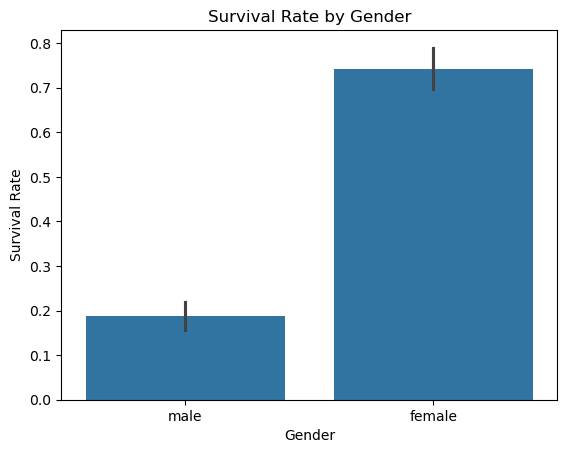

In [18]:
sns.barplot(x="Sex", y="Survived", data=df)

plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")

plt.show()

## Step 11: Analyze Survival by Passenger Class

This analysis examines whether passenger class affected the probability of survival.

In [19]:
df.groupby("Pclass")["Survived"].mean()

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

## Step 12: Visualization – Survival by Passenger Class

A bar chart is created to compare the survival rate across different passenger classes.

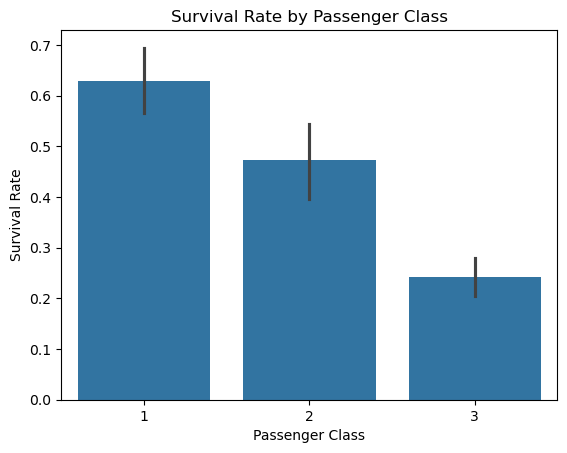

In [20]:
sns.barplot(x="Pclass", y="Survived", data=df)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.show()

## Step 13: Create Age Groups

To better understand how age influenced survival, passengers are divided into five age categories:

- Child (0–12 years)
- Teen (13–18 years)
- Young Adult (19–35 years)
- Adult (36–60 years)
- Senior (Above 60 years)

This makes it easier to compare survival rates across different age groups.

In [26]:
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child", "Teen", "Young Adult", "Adult", "Senior"]

df["AgeGroup"] = pd.cut(df["Age"], bins=bins, labels=labels)

## Step 14: Analyze Survival by Age Group

The average survival rate is calculated for each age group to determine which age category had the highest and lowest chances of survival.

In [28]:
df.groupby("AgeGroup")["Survived"].mean()

C:\Users\abhis\AppData\Local\Temp\ipykernel_11036\2602041343.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("AgeGroup")["Survived"].mean()


AgeGroup
Child          0.579710
Teen           0.428571
Young Adult    0.353271
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64

### Insight

The analysis shows that children had the highest survival rate, while senior passengers had the lowest survival rate. This suggests that younger passengers had a better chance of survival during the Titanic disaster.

## Step 15: Visualization – Survival Rate by Age Group

A bar chart is created to compare the survival rate across different age groups. This visualization helps identify which age category had the highest and lowest chances of survival.

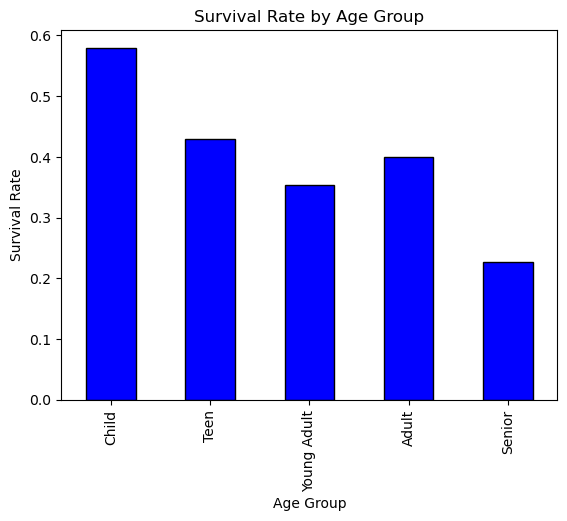

In [32]:
age_survival.plot(
    kind="bar",
    color="blue",
    edgecolor="black"
)

plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")

plt.show()

## Step 16: Visualization – Passenger Age Distribution

A histogram is created to visualize the distribution of passenger ages. This graph helps identify the most common age groups among the passengers.

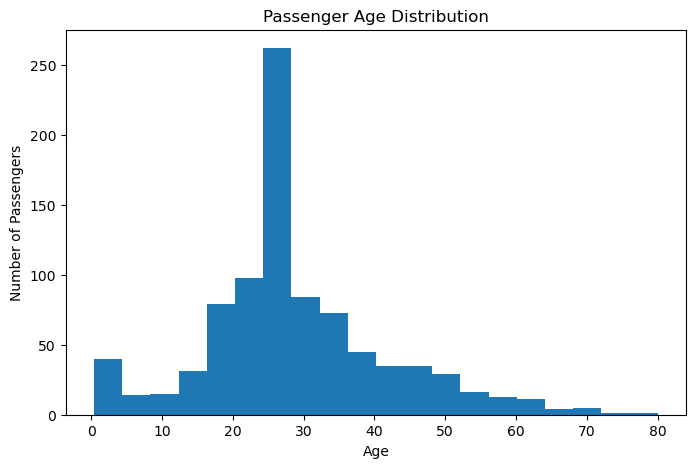

In [29]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Passenger Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

### Insight

The histogram indicates that most passengers were young adults. The number of children and senior passengers was comparatively lower.

# Conclusion

This project analyzed the Titanic dataset using Python, Pandas, Matplotlib, and Seaborn.

### Key Findings

- Female passengers had a higher survival rate than male passengers.
- First-class passengers had better survival chances than second- and third-class passengers.
- Children showed the highest survival rate among all age groups.
- Senior passengers had the lowest survival rate.
- Missing values in the Age column were successfully handled using the median value.
- Data visualization made it easier to identify survival patterns and understand the dataset.

Overall, this analysis demonstrates how data cleaning, exploratory data analysis, and visualization can be used to extract meaningful insights from real-world datasets.

In [21]:
print("Conclusion:")
print("1. Females had a higher survival rate than males.")
print("2. First-class passengers survived more than second and third class.")
print("3. Young adults made up the largest age group.")
print("4. Missing Age values were replaced with the median.")

Conclusion:
1. Females had a higher survival rate than males.
2. First-class passengers survived more than second and third class.
3. Young adults made up the largest age group.
4. Missing Age values were replaced with the median.


# Thank You

This notebook was prepared as part of the **Data Science with Python Internship – Task 2**.

It demonstrates data loading, data cleaning, exploratory data analysis, and visualization using the Titanic dataset.